# Dirty Cafe Sales Analysis
### Business Scenario
You have been hired as a data analyst by a cafe. The cafe has provided trasnaction data and want to understand their performance.

In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# load data. read_csv function is used to read the csv file and store it in a dataframe which is like a table
df = pd.read_csv("dirty_cafe_sales.csv")

In [4]:
# dataset shape
df.shape

(10000, 8)

In [5]:
# know the columns in the dataset
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='str')

In [6]:
# preview the data
df.head() # no argument means it will show the first 5 rows of the dataset. You can also specify the number of rows you want to see by passing an integer as an argument to the head() function. For example, df.head(10) will show the first 10 rows of the dataset.

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [7]:
# last 5 rows of the dataset
df.tail()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


In [8]:
#NaN shows the value is missing
# when we want to take a random set of rows from the dataset to evaluate
df.sample(16)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
7859,TXN_4898346,Smoothie,2,4.0,8.0,Cash,NaN,2023-05-07
7175,TXN_5594043,Cake,4,3.0,12.0,Cash,NaN,2023-06-22
1327,TXN_6717061,Salad,3,5.0,15.0,Credit Card,NaN,2023-08-07
6760,TXN_8018272,Smoothie,4,4.0,ERROR,NaN,NaN,2023-03-01
9058,TXN_5672583,Juice,2,3.0,NaN,Cash,Takeaway,2023-04-09
1771,TXN_3981000,Tea,1,1.5,1.5,Digital Wallet,In-store,2023-05-24
987,TXN_1104849,UNKNOWN,4,4.0,16.0,Digital Wallet,Takeaway,2023-07-05
4244,TXN_1892454,Juice,1,3.0,3.0,UNKNOWN,NaN,2023-07-19
6186,TXN_4702345,Salad,4,5.0,20.0,Digital Wallet,NaN,2023-01-08
8701,TXN_8014289,Juice,5,3.0,15.0,Digital Wallet,In-store,2023-12-04


In [9]:
# we can see the various rows with wrong data
# now we want to get the dataframe info so we can better understand our dataset. The info() function will give us the number of non-null values in each column, the data type of each column, and the memory usage of the dataframe.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [10]:
# we can see most of the columns have missing values except transaction id.
# some of the columns also have wrong dataset like quantity, price, total spent, date
# very important to run df.info() on any new dataset to understand the data types and missing values. This will help us to clean the data and prepare it for analysis.


There are some missing values and incorrect data types in the dataframe

In [11]:
# statistical summary of the dataset. The describe() function will give us the count, mean, standard deviation, minimum, maximum, and quartiles of the numerical columns in the dataframe. if not numeric, it gives the count, unique, top, and freq of the categorical columns in the dataframe.
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [12]:
# selecting a column from the dataframe. We can select a column by using the column name in square brackets. For example, df['column_name'] will return a series of the column values. We can also use the dot notation to select a column. For example, df.column_name will return a series of the column values.
df["Item"]

0         Coffee
1           Cake
2         Cookie
3          Salad
4         Coffee
          ...   
9995      Coffee
9996         NaN
9997      Coffee
9998      Cookie
9999    Sandwich
Name: Item, Length: 10000, dtype: str

In [13]:
# what has been returned is a series. A series is a one-dimensional array-like object that can hold any data type. It is similar to a list in Python. We can convert a series to a dataframe by using the to_frame() function. For example, df['column_name'].to_frame() will return a dataframe with one column.

In [14]:
# select multiple columns from the dataframe. We can select multiple columns by passing a list of column names to the square brackets. For example, df[['column_name1', 'column_name2']] will return a dataframe with the specified columns.
df[["Item", "Quantity", "Price Per Unit"]]

,Item,Quantity,Price Per Unit
0,Coffee,2,2.0
1,Cake,4,3.0
2,Cookie,4,1.0
3,Salad,2,5.0
4,Coffee,2,2.0
...,...,...,...
9995,Coffee,2,2.0
9996,NaN,3,NaN
9997,Coffee,4,2.0
9998,Cookie,3,NaN


In [15]:
# checking data types of columns
df.dtypes

Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

Now we are doing data quality checks

In [16]:
# checking the missing values. isnull() function will return a dataframe of the same shape as the original dataframe with True for missing values and False for non-missing values. We can use the sum() function to get the total number of missing values in each column.
df.isnull().sum()


Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [17]:
# method  2 to check for missing values
df.isna().sum() # isna() function is similar to isnull() function. It will return a dataframe of the same shape as the original dataframe with True for missing values and False for non-missing values. We can use the sum() function to get the total number of missing values in each column.

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [18]:
# duplicate records. duplicated() function will return a series of boolean values indicating whether each row is a duplicate or not. We can use the sum() function to get the total number of duplicate rows in the dataframe.
df.duplicated().sum()

np.int64(0)

In [19]:
# so we have no duplicates.

In [20]:
# when you find duplicates, investigate first if they should be there or not

## Data Cleaning
Order matters in data cleaning
1. There are hidden invalid values like: 'UNKNOWN', 'ERROR', 'NA', '?', etc. You need to first convert these hidden values before converting the values of that column from say str to int otherwise you will get errors. [Order applies there]. Not all rows have these invalids so thats why sampling and previewing helps to know that.
2. Incorrect data types
3. Remove missing values
4. Deal with case: 'coffee' != 'Coffee' != 'COFFEE'

In [21]:
# Replace invalid values with NaN (missing value)
invalid_values = ['UNKNOWN', 'ERROR', 'NA', '?']
df.replace(invalid_values, np.nan, inplace=True)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [22]:
# Recheck number of missing values after replacing invalid values with NaN
df.isnull().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [23]:
# Fixing the incorrect data types. We can use the astype() function to change the data type of a column. For example, df['column_name'] = df['column_name'].astype('data_type') will change the data type of the specified column to the specified data type. We can also use the to_datetime() function to convert a column to datetime format. For example, df['column_name'] = pd.to_datetime(df['column_name']) will convert the specified column to datetime format.
# Change the 3 columns to numeric
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce') # errors='coerce' will replace the invalid values with NaN
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

In [24]:
df.dtypes

Transaction ID          str
Item                    str
Quantity            float64
Price Per Unit      float64
Total Spent         float64
Payment Method          str
Location                str
Transaction Date        str
dtype: object

In [25]:
# change transaction date to datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

In [26]:
df.isnull().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [27]:
# this data conversion process creates more nans so its better not to drop missing values initially. do it after the conversion step
# Drop missing values
df = df.dropna() 

In [28]:
df.info()

<class 'pandas.DataFrame'>
Index: 3089 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    3089 non-null   str           
 1   Item              3089 non-null   str           
 2   Quantity          3089 non-null   float64       
 3   Price Per Unit    3089 non-null   float64       
 4   Total Spent       3089 non-null   float64       
 5   Payment Method    3089 non-null   str           
 6   Location          3089 non-null   str           
 7   Transaction Date  3089 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 217.2 KB


In [29]:
# clean the data
df['Item'] = df['Item'].str.strip().str.title()

## Validation
Ensuring the changes we made to our data worked.

In [30]:
# Recheck for missing values
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [31]:
# Check dataset shape. That is no. of rows and columns. We had 10,000 rows initially
df.shape

(3089, 8)

In [32]:
# Check the items to make sure items don't appear severally. like Coffee and coffee
df['Item'].unique()

<StringArray>
['Coffee', 'Cake', 'Salad', 'Sandwich', 'Juice', 'Smoothie', 'Cookie', 'Tea']
Length: 8, dtype: str

In [33]:
# All items are in title case and none appears twice

In [34]:
# Recheck data types
df.dtypes

Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

In [35]:
# Summary of statistics
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,3089.000000,3089.000000,3089.000000,3089
mean,3.023632,2.954030,8.936711,2023-07-01 07:14:28.242149
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00
25%,2.000000,2.000000,4.000000,2023-03-28 00:00:00
50%,3.000000,3.000000,8.000000,2023-07-06 00:00:00
75%,4.000000,4.000000,12.000000,2023-10-01 00:00:00
max,5.000000,5.000000,25.000000,2023-12-31 00:00:00
std,1.418931,1.292975,6.032656,NaN


In [36]:
# this statistical analysis also helps us spot a data value that is an outlier as it will deviate alot from the norm values shown

## Business Questions

In [37]:
# How many times was each product/item sold?
df['Item'].value_counts()
# this counts for each item how many times it appears in the dataset. each entry is a sale

Item
Juice       427
Salad       418
Sandwich    391
Cookie      391
Cake        385
Tea         372
Coffee      367
Smoothie    338
Name: count, dtype: int64

In [38]:
# What is our best seller?
df['Item'].value_counts().idxmax()
# returns the label of the index wit hthe highest value

'Juice'

In [39]:
# What is the average quantity ordered per transaction?
df['Quantity'].mean()

np.float64(3.0236322434444802)

In [40]:
# What is the total quantity sold?
df['Quantity'].sum()

np.float64(9340.0)

In [41]:
# Creating new column
df['Revenue'] = df['Quantity'] * df['Price Per Unit']

In [42]:
# previre the data
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Revenue
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,4.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,12.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,4.0
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07,25.0
12,TXN_7619095,Sandwich,2.0,4.0,8.0,Cash,In-store,2023-05-03,8.0


In [43]:
# Total revenue?
df['Revenue'].sum()

np.float64(27605.5)

In [44]:
# Total revenue of each item?
df.groupby('Item')['Revenue'].sum()
# group revenue by items

Item
Cake        3519.0
Coffee      2242.0
Cookie      1163.0
Juice       3735.0
Salad       6360.0
Sandwich    4772.0
Smoothie    4088.0
Tea         1726.5
Name: Revenue, dtype: float64

In [45]:
# Sort revenue per items
df.groupby('Item')['Revenue'].sum().sort_values(ascending=False)

Item
Salad       6360.0
Sandwich    4772.0
Smoothie    4088.0
Juice       3735.0
Cake        3519.0
Coffee      2242.0
Tea         1726.5
Cookie      1163.0
Name: Revenue, dtype: float64

In [46]:
# What is quantity sold per location?
df.groupby('Location')['Quantity'].sum()

Location
In-store    4674.0
Takeaway    4666.0
Name: Quantity, dtype: float64

## Visualization

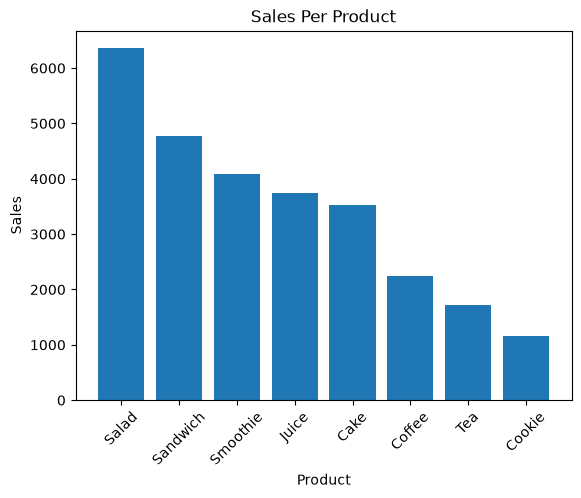

In [47]:
# show sales per product
sales_per_item = df.groupby('Item')['Revenue'].sum().sort_values(ascending=False)
# we are comparing values so we use bar chart
plt.bar(sales_per_item.index, sales_per_item.values)
# x-axis, y-axis
plt.title('Sales Per Product')
plt.xlabel('Product')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()


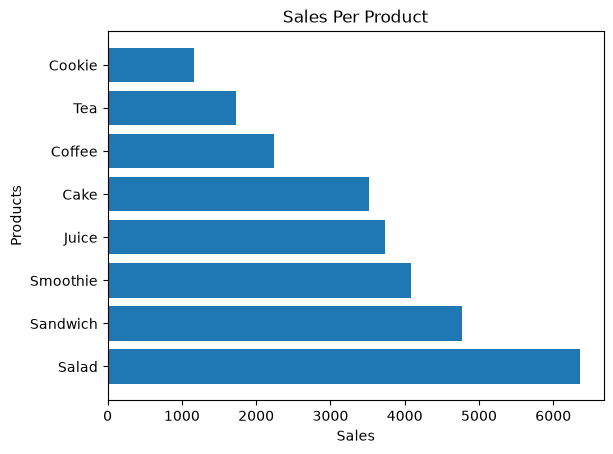

In [48]:
# horizontal barchart is usually better at visualization than vertical
plt.barh(sales_per_item.index, sales_per_item.values)
plt.title('Sales Per Product')
plt.xlabel('Sales')
plt.ylabel('Products')
plt.show()

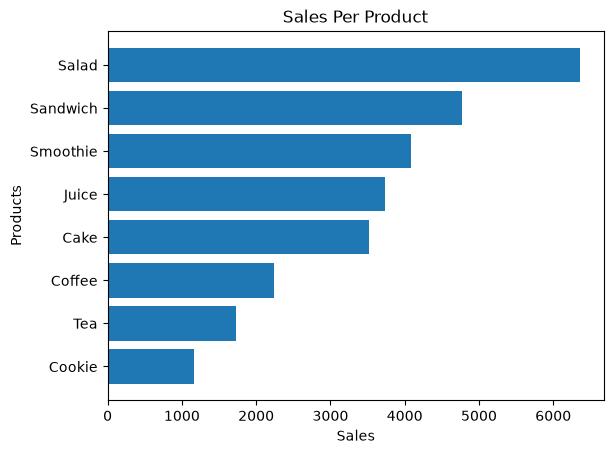

In [ ]:
# invert the order as it appears on the chart. start with the highest
plt.barh(sales_per_item.index[::-1], sales_per_item.values[::-1])
plt.title('Sales Per Product')
plt.xlabel('Sales')
plt.ylabel('Products')
plt.show()

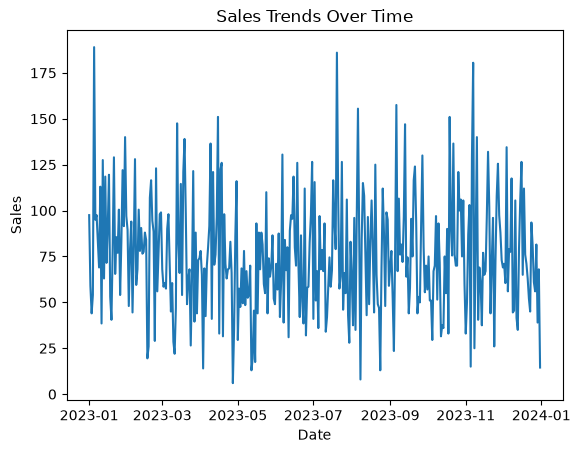

In [50]:
# sales trend over time
daily_sales = df.groupby('Transaction Date')['Revenue'].sum()
plt.plot(daily_sales.index, daily_sales.values)
plt.title('Sales Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

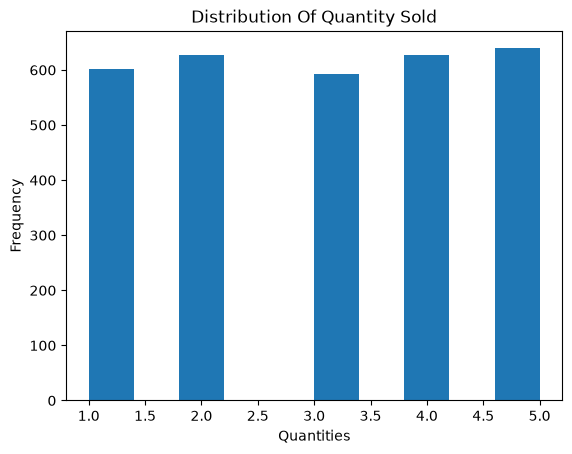

In [51]:
# Show how quantities are distributed
plt.hist(df['Quantity'], bins=10)
plt.title('Distribution Of Quantity Sold')
plt.xlabel('Quantities')
plt.ylabel('Frequency')
plt.show()

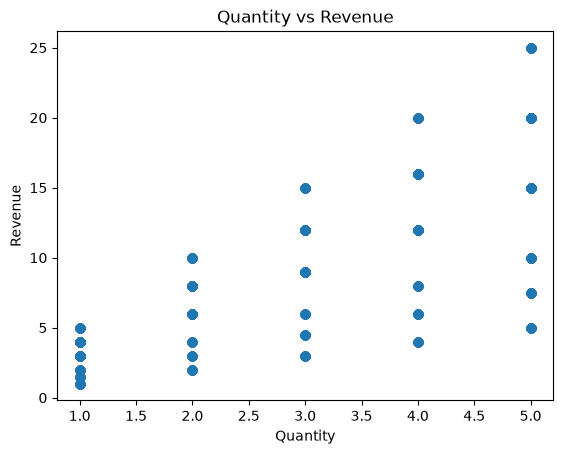

In [52]:
# Scatter plot investigates whether 2 entities are related
# is there a relationship between quantity sold and revenue
plt.scatter(df['Quantity'], df['Revenue'])
plt.title('Quantity vs Revenue')
plt.xlabel('Quantity')
plt.ylabel('Revenue')
plt.show()

We can see the quantity and revenue are related. increase in quantity sold leads to increase in revenue.